# Real vs Fake Trump Tweet Classification

**Deep Learning Project **

This notebook trains and compares five text classifiers on the task of telling **real** Donald Trump tweets apart from **fake** tweets generated by simple statistical models.

In [2]:
import os
import torch

In [ ]:
%%writefile data_loader.py
"""
data_loader.py
--------------
Shared data loading utility for the real-vs-fake tweet classifier.

What it does:
- Loads real Trump tweets from tweets.csv (filtering out retweets / deletions)
- Loads fake tweets generated with the 4-gram Markov model
- Labels them: 1 = real, 0 = fake
- Returns a consistent train/test split with a fixed random seed so every
  classifier sees the exact same split, making comparisons fair
"""

import json
import pandas as pd
from sklearn.model_selection import train_test_split

# Paths 
REAL_PATH = "tweets.csv"
FAKE_PATH = "fake_tweets_3.json"

# Fixed random seed so every classifier gets the same split.
RANDOM_SEED = 42


def load_real_tweets(path: str = REAL_PATH) -> list[str]:
    """Load and clean real Trump tweets. Filter retweets + deleted."""
    df = pd.read_csv(path)
    df = df[df["isRetweet"] == "f"]
    df = df[df["isDeleted"] == "f"]
    # Drop near-empty tweets (just a URL or whitespace)
    # 45,454-tweet figure once filtered.
    df = df[df["text"].str.strip().str.len() > 0]
    return df["text"].astype(str).tolist()


def load_fake_tweets(path: str = FAKE_PATH) -> list[str]:
    """Load 4-gram fake tweets."""
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def get_data(test_size: float = 0.2, max_per_class: int | None = None):
    """
    Build the combined dataset with labels and split into train/test.

    Args:
        test_size: fraction held out for testing (default 20%)
        max_per_class: optional cap for quick experiments


    Returns:
        X_train, X_test, y_train, y_test
        Where X is a list[str] (tweet texts) and y is a list[int]
        (1 = real, 0 = fake).
    """
    real = load_real_tweets()
    fake = load_fake_tweets()

    if max_per_class is not None:
        real = real[:max_per_class]
        fake = fake[:max_per_class]

    print(f"Loaded {len(real):,} real tweets and {len(fake):,} fake tweets.")

    # Labels: 1 for real, 0 for fake.
    X = real + fake
    y = [1] * len(real) + [0] * len(fake)

    # Stratified split keeps the class balance equal in train and test.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=RANDOM_SEED,
        stratify=y,
    )

    print(f"Train size: {len(X_train):,}   Test size: {len(X_test):,}")
    return X_train, X_test, y_train, y_test


if __name__ == "__main__":
    # Sanity check — run "python data_loader.py" to confirm everything loads.
    X_train, X_test, y_train, y_test = get_data()
    print("\nSample real tweet:", X_train[y_train.index(1)][:120])
    print("Sample fake tweet:", X_train[y_train.index(0)][:120])


Overwriting data_loader.py


In [4]:
%%writefile tokenizer_util.py
"""
tokenizer_util.py
-----------------

- We want to SAVE the tokenizer alongside the model and reload it
  during evaluation, which keeps eval clean and reproducible

Special tokens (always at fixed indices):
    0 = <pad>   used to right-pad all sequences to the same length
    1 = <unk>   any word not in the vocabulary at training time
"""

import json
import re
from collections import Counter


PAD_IDX = 0
UNK_IDX = 1
SPECIAL_TOKENS = ["<pad>", "<unk>"]


def simple_tokenize(text: str) -> list[str]:
    """
    Very simple tokenization: lowercase, then split on non-word characters
    while keeping punctuation as separate tokens. Good enough for tweets.

    Examples:
        "Sleepy Joe is at it again!"
        -> ['sleepy', 'joe', 'is', 'at', 'it', 'again', '!']
    """
    text = text.lower()
    # Replace URLs with a placeholder token so the model can learn that
    # "tweets containing a URL" is itself a feature, without exploding vocab
    text = re.sub(r"https?://\S+", " <url> ", text)
    # Split on word characters; keep punctuation as separate tokens
    tokens = re.findall(r"[a-z0-9<>_]+|[^\w\s]", text)
    return tokens


class Tokenizer:
    """Word-level tokenizer with save/load."""

    def __init__(self, vocab_size: int = 20_000, min_freq: int = 2):
        self.vocab_size = vocab_size
        self.min_freq = min_freq
        self.word2idx: dict[str, int] = {}
        self.idx2word: list[str] = []

    def fit(self, texts: list[str]) -> None:
        """Build the vocabulary from a list of training texts."""
        counter: Counter = Counter()
        for t in texts:
            counter.update(simple_tokenize(t))

        # Reserve indices 0..len(SPECIAL_TOKENS)-1 for special tokens
        self.idx2word = list(SPECIAL_TOKENS)
        for word, freq in counter.most_common():
            if freq < self.min_freq:
                break
            if len(self.idx2word) >= self.vocab_size:
                break
            self.idx2word.append(word)

        self.word2idx = {w: i for i, w in enumerate(self.idx2word)}
        print(f"  Built vocabulary: {len(self.idx2word):,} tokens "
              f"(asked for max {self.vocab_size:,})")

    def encode(self, text: str, max_len: int) -> list[int]:
        """Encode a single text into a list of token IDs of length max_len.
        Pads with PAD_IDX (0) on the right; truncates if too long."""
        ids = [self.word2idx.get(w, UNK_IDX) for w in simple_tokenize(text)]
        ids = ids[:max_len]
        ids = ids + [PAD_IDX] * (max_len - len(ids))
        return ids

    def encode_batch(self, texts: list[str], max_len: int) -> list[list[int]]:
        return [self.encode(t, max_len) for t in texts]

    @property
    def vocab_len(self) -> int:
        return len(self.idx2word)

    def save(self, path: str) -> None:
        with open(path, "w", encoding="utf-8") as f:
            json.dump({
                "vocab_size": self.vocab_size,
                "min_freq": self.min_freq,
                "idx2word": self.idx2word,
            }, f, ensure_ascii=False)

    @classmethod
    def load(cls, path: str) -> "Tokenizer":
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        tok = cls(vocab_size=data["vocab_size"], min_freq=data["min_freq"])
        tok.idx2word = data["idx2word"]
        tok.word2idx = {w: i for i, w in enumerate(tok.idx2word)}
        return tok


if __name__ == "__main__":
    # Quick sanity test
    t = Tokenizer(vocab_size=100, min_freq=1)
    t.fit(["Sleepy Joe is at it again!", "The economy is GREAT!"])
    enc = t.encode("Joe is great", max_len=10)
    print("Encoded:", enc)
    t.save("/tmp/tok_test.json")
    t2 = Tokenizer.load("/tmp/tok_test.json")
    print("Reloaded vocab size:", t2.vocab_len)


Writing tokenizer_util.py


## Classifier 1 — TF-IDF + Logistic Regression (Baseline)

A simple bag of words baseline. We count which words and word-pairs appear in each tweet (weighting rare but informative terms higher with TF-IDF), then train a linear classifier. Trains in seconds and gives us the **floor** that all deep learning models must beat.




- A tweet is just a "bag of words" that we count which words appear.
- TF-IDF weights rare-but-informative words more than common ones
  ("Hillary" carries info, "the" doesn't).
- Logistic regression draws a linear boundary in that word-count space:
  "if these words appear, the tweet is more likely to be real (or fake)."
- We use both 1-grams AND 2-grams (single words and pairs) because a
  pair like "fake news" carries more signal than "fake" and "news"
  separately.




Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299

Fitting TF-IDF vectorizer...
Vocab size: 20,000

Training for 8 epochs...
  Epoch 1/8  loss=0.5708  val_loss=0.6936
  Epoch 2/8  loss=0.5501  val_loss=0.6679
  Epoch 3/8  loss=0.5433  val_loss=0.6588
  Epoch 4/8  loss=0.5401  val_loss=0.6541
  Epoch 5/8  loss=0.5384  val_loss=0.6515
  Epoch 6/8  loss=0.5375  val_loss=0.6499
  Epoch 7/8  loss=0.5370  val_loss=0.6488
  Epoch 8/8  loss=0.5367  val_loss=0.6481

=== Test results ===
Accuracy: 0.5858
              precision    recall  f1-score   support

        fake       0.57      0.69      0.62      9091
        real       0.61      0.48      0.54      9208

    accuracy                           0.59     18299
   macro avg       0.59      0.59      0.58     18299
weighted avg       0.59      0.59      0.58     18299

[[6307 2784]
 [4796 4412]]


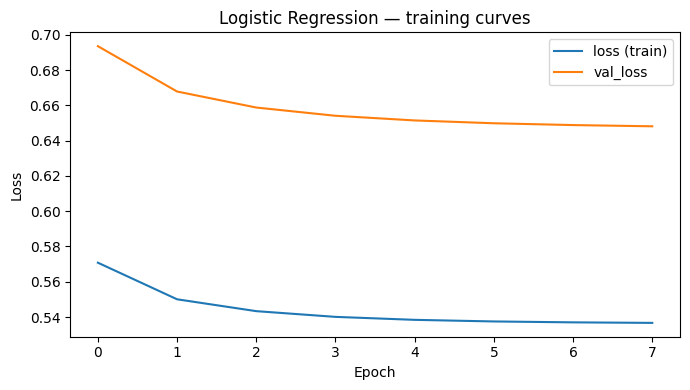

Saved: model_01_logreg.joblib, history_01_logreg.json, curves_01_logreg.png


In [ ]:
"""
Classifier 1 — TF-IDF + Logistic Regression (with training curve)
"""
import numpy as np
import json
import joblib
from sklearn.linear_model import SGDClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from data_loader import get_data

# Load data + carve val set (10% of training)
X_train, X_test, y_train, y_test = get_data()
n_val = int(0.1 * len(X_train))
X_val, y_val = X_train[-n_val:], y_train[-n_val:]
X_train, y_train = X_train[:-n_val], y_train[:-n_val]

# TF-IDF features 
print("\nFitting TF-IDF vectorizer...")
vectorizer = TfidfVectorizer(
    max_features=20_000, ngram_range=(1, 2), min_df=2, lowercase=True,
)
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec   = vectorizer.transform(X_val)
X_test_vec  = vectorizer.transform(X_test)
print(f"Vocab size: {len(vectorizer.vocabulary_):,}")

# SGDClassifier with log_loss = logistic regression with SGD,
# which lets us track loss per epoch via partial_fit
EPOCHS = 8
model = SGDClassifier(loss='log_loss', learning_rate='optimal',
                      alpha=1e-5, random_state=42)

history = {"loss": [], "val_loss": []}
y_train_arr, y_val_arr = np.array(y_train), np.array(y_val)

print(f"\nTraining for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    if epoch == 0:
        model.partial_fit(X_train_vec, y_train_arr, classes=[0, 1])
    else:
        model.partial_fit(X_train_vec, y_train_arr)

    train_p = np.clip(model.predict_proba(X_train_vec)[:, 1], 1e-7, 1 - 1e-7)
    val_p   = np.clip(model.predict_proba(X_val_vec)[:, 1],   1e-7, 1 - 1e-7)
    train_loss = -np.mean(y_train_arr * np.log(train_p) + (1 - y_train_arr) * np.log(1 - train_p))
    val_loss   = -np.mean(y_val_arr   * np.log(val_p)   + (1 - y_val_arr)   * np.log(1 - val_p))
    history["loss"].append(float(train_loss))
    history["val_loss"].append(float(val_loss))
    print(f"  Epoch {epoch+1}/{EPOCHS}  loss={train_loss:.4f}  val_loss={val_loss:.4f}")

# Test evaluation
y_pred = model.predict(X_test_vec)
print("\n=== Test results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=["fake", "real"]))
print(confusion_matrix(y_test, y_pred))

# Training curve plot (same style as classifiers 2/3/4)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["loss"], label="loss (train)")
ax.plot(history["val_loss"], label="val_loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Logistic Regression — training curves")
ax.legend()
plt.tight_layout()
plt.savefig("curves_01_logreg.png", dpi=150)
plt.show()

# Save
joblib.dump((vectorizer, model), "model_01_logreg.joblib")
with open("history_01_logreg.json", "w") as f:
    json.dump(history, f)
print("Saved: model_01_logreg.joblib, history_01_logreg.json, curves_01_logreg.png")


## Classifier 2 — Embedding + MLP

Each word gets converted into a learned 64-dimensional vector (an "embedding"), all the vectors in a tweet are averaged, and the result is fed through a small feed forward network. This is the simplest neural approach but still word order is ignored, but with learned representations instead of hand-crafted TF-IDF counts.




- Tweets are short (<= 60 tokens), so a heavyweight sequence model is overkill
- A learned embedding lets the model discover useful word-level features
  that the baseline (#1) can't (e.g., that "BIGLY" patterns
  with "Tremendous" but is rare with "Hillary")
- Average pooling is a deliberate weakness: it ignores word order. We use
  it here to provide a clean stepping stone from to LSTM.

REGULARIZATION CHOICES:
- Dropout (p=0.3) between layers to reduce overfitting
- Weight decay = 1e-5 on the optimizer (mild L2)
- Early stopping on validation loss

OPTIMIZER: Adam, lr=1e-3. Standard for small NLP models, robust default.
LOSS:      BCEWithLogitsLoss (binary, more numerically stable than
           sigmoid + BCELoss).

Device: cuda
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299

Fitting tokenizer...
  Built vocabulary: 20,000 tokens (asked for max 20,000)

Model:
EmbeddingMLP(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (relu): ReLU()
)
Total parameters: 1,284,225

Training...
  Epoch  1/8  loss=0.6484 acc=0.6079  val_loss=0.6114 val_acc=0.6784
  Epoch  2/8  loss=0.5786 acc=0.7014  val_loss=0.5490 val_acc=0.7293
  Epoch  3/8  loss=0.5233 acc=0.7427  val_loss=0.5103 val_acc=0.7576
  Epoch  4/8  loss=0.4802 acc=0.7719  val_loss=0.4905 val_acc=0.7651
  Epoch  5/8  loss=0.4495 acc=0.7912  val_loss=0.4763 val_acc=0.7788
  Epoch  6/8  loss=0.4241 acc=0.8074  val_loss=0.4763 val_acc=0.7818
  Epoch  7/8  loss=0.4017 acc=0.8222  val_loss=0.4642 val_acc=0.7788
  Epoch  8/8  loss=0.3837 acc=0.8312  val

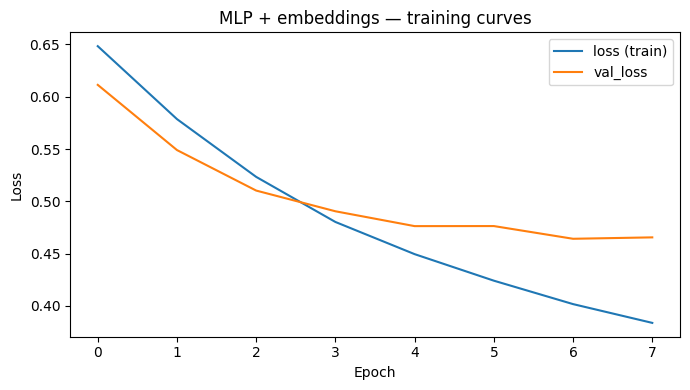

In [6]:
"""
02_mlp_embedding.py
-------------------------------------
CLASSIFIER #2 — Word embeddings + average pool + small MLP.

"""

import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

from data_loader import get_data
from tokenizer_util import Tokenizer, PAD_IDX


# ------------------------- Hyperparameters -------------------------
VOCAB_SIZE = 20_000
MAX_LEN = 60
EMBED_DIM = 64
HIDDEN_DIM = 64
DROPOUT = 0.3
BATCH_SIZE = 128
EPOCHS = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 2     # early stopping: stop if val loss doesn't improve N epochs
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------- Dataset -------------------------
class TweetDataset(Dataset):
    """Holds (token_ids, label) tensors."""
    def __init__(self, texts, labels, tokenizer, max_len):
        self.ids = torch.tensor(
            tokenizer.encode_batch(texts, max_len), dtype=torch.long
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.ids[i], self.labels[i]


# ------------------------- Model -------------------------
class EmbeddingMLP(nn.Module):
    """
    Architecture:
        token_ids -> embedding -> masked mean pool -> Linear -> ReLU
                                                   -> Dropout -> Linear -> logit
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()
        # padding_idx=PAD_IDX so that pad tokens have a zero embedding
        # and don't contribute gradient
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=PAD_IDX)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (batch, max_len) of token IDs
        emb = self.embedding(x)            # (batch, max_len, embed_dim)
        # Mean over non-padded positions:
        mask = (x != PAD_IDX).unsqueeze(-1).float()        # (batch, max_len, 1)
        summed = (emb * mask).sum(dim=1)                   # (batch, embed_dim)
        counts = mask.sum(dim=1).clamp(min=1.0)            # avoid /0
        pooled = summed / counts                           # (batch, embed_dim)

        h = self.relu(self.fc1(pooled))
        h = self.dropout(h)
        logit = self.fc2(h).squeeze(-1)    # (batch,)
        return logit


# ------------------------- Train / eval helpers -------------------------
def run_epoch(model, loader, optimizer, criterion, train):
    model.train() if train else model.eval()
    total_loss, n, n_correct = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for ids, labels in loader:
            ids, labels = ids.to(DEVICE), labels.to(DEVICE)
            logits = model(ids)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            preds = (torch.sigmoid(logits) >= 0.5).float()
            n_correct += (preds == labels).sum().item()
            n += labels.size(0)
            total_loss += loss.item() * labels.size(0)
    return total_loss / n, n_correct / n


def main():
    torch.manual_seed(SEED)
    print(f"Device: {DEVICE}")

    # 1) Data
    X_train, X_test, y_train, y_test = get_data()

    # Split off a validation set from training (10%)
    n_val = int(0.1 * len(X_train))
    X_val, y_val = X_train[-n_val:], y_train[-n_val:]
    X_train, y_train = X_train[:-n_val], y_train[:-n_val]

    # 2) Tokenizer — fit on TRAINING data only (don't leak val/test)
    print("\nFitting tokenizer...")
    tokenizer = Tokenizer(vocab_size=VOCAB_SIZE, min_freq=2)
    tokenizer.fit(X_train)

    # 3) Datasets + loaders
    train_ds = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
    val_ds   = TweetDataset(X_val,   y_val,   tokenizer, MAX_LEN)
    test_ds  = TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

    # 4) Model, loss, optimizer
    model = EmbeddingMLP(
        vocab_size=tokenizer.vocab_len,
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ).to(DEVICE)
    print("\nModel:")
    print(model)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {n_params:,}")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    )

    # 5) Training loop with early stopping
    history = {"loss": [], "val_loss": [], "acc": [], "val_acc": []}
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_state = None

    print("\nTraining...")
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, criterion, True)
        va_loss, va_acc = run_epoch(model, val_loader,   optimizer, criterion, False)
        history["loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        print(f"  Epoch {epoch:2d}/{EPOCHS}  "
              f"loss={tr_loss:.4f} acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}.")
                break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # 6) Final evaluation on test set
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for ids, labels in test_loader:
            ids = ids.to(DEVICE)
            logits = model(ids)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy().astype(int))

    print("\n=== Test results ===")
    print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    print(classification_report(all_labels, all_preds, target_names=["fake", "real"]))
    print(confusion_matrix(all_labels, all_preds))

    # 7) Save model, tokenizer, history
    torch.save({
        "model_state_dict": model.state_dict(),
        "config": {
            "vocab_size": tokenizer.vocab_len,
            "embed_dim": EMBED_DIM,
            "hidden_dim": HIDDEN_DIM,
            "dropout": DROPOUT,
            "max_len": MAX_LEN,
        },
    }, "model_02_mlp.pt")
    tokenizer.save("tokenizer_02.json")
    with open("history_02_mlp.json", "w") as f:
        json.dump(history, f)
    print("\nSaved: model_02_mlp.pt, tokenizer_02.json, history_02_mlp.json")

    # 8) Loss curve plot
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history["loss"], label="loss (train)")
    ax.plot(history["val_loss"], label="val_loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("MLP + embeddings — training curves")
    ax.legend()
    plt.tight_layout()
    plt.savefig("curves_02_mlp.png", dpi=150)
    print("Saved: curves_02_mlp.png")


if __name__ == "__main__":
    main()


## Classifier 3 — Bidirectional LSTM

LIMITATIONS WE EXPECT:
- The 4-gram fakes already disrupt order locally (~3-token windows).
  An LSTM might struggle to catch this because the local order looks fine;
  it's the long-range coherence that breaks.

REGULARIZATION:
- Dropout in the LSTM (between stacked layers if num_layers>1)
- Dropout on the classifier head
- Weight decay on the optimizer
- Early stopping on val loss

OPTIMIZER: Adam, lr=1e-3, weight_decay=1e-5.
LOSS:      BCEWithLogitsLoss.

Unlike the MLP, **word order matters** here.



Device: cuda
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299

Fitting tokenizer...
  Built vocabulary: 20,000 tokens (asked for max 20,000)

Model:
BiLSTMClassifier(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)
Total parameters: 1,346,689

Training...
  Epoch  1/8  loss=0.5278 acc=0.7127  val_loss=0.3905 val_acc=0.8220
  Epoch  2/8  loss=0.3521 acc=0.8399  val_loss=0.3411 val_acc=0.8441
  Epoch  3/8  loss=0.3070 acc=0.8641  val_loss=0.3342 val_acc=0.8496
  Epoch  4/8  loss=0.2698 acc=0.8842  val_loss=0.3044 val_acc=0.8645
  Epoch  5/8  loss=0.2326 acc=0.9027  val_loss=0.2978 val_acc=0.8757
  Epoch  6/8  loss=0.2002 acc=0.9193  val_loss=0.2945 val_acc=0.8755
  Epoch  7/8  loss=0.1675 acc=0.9342  val_loss=0.3075 val_acc=0.8781
  Epoch  8/8  loss=0.1387 acc=0.9464  val_los

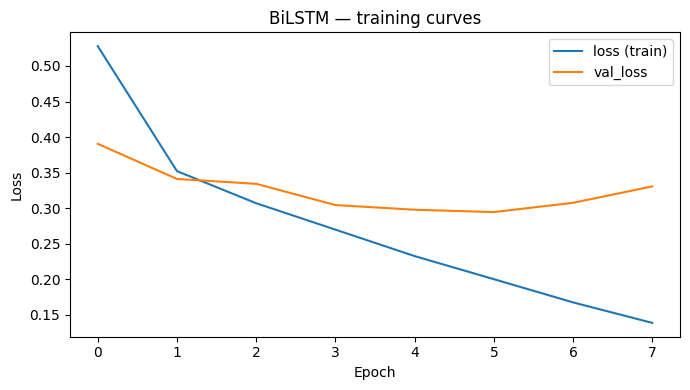

In [7]:
"""
03_rnn_lstm.py
--------------------------------
CLASSIFIER #3 — Bidirectional LSTM encoder + classifier head.

- An LSTM reads the tweet ONE WORD AT A TIME, maintaining a hidden state
  that captures the sequence so far. This is: h_t = f(x_t, h_{t-1})

- Bidirectional: we read left->right AND right->left, then concatenate
  both summaries. This helps because some style markers depend on context
  from both sides (e.g., capitalization patterns in mid tweet).

- We use the LAST hidden state from each direction (concatenated) as
  our "tweet summary," then pass it through a small classifier head.

"""
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

from data_loader import get_data
from tokenizer_util import Tokenizer, PAD_IDX


VOCAB_SIZE = 20_000
MAX_LEN = 60
EMBED_DIM = 64
LSTM_HIDDEN = 64
LSTM_LAYERS = 1
DROPOUT = 0.3
BATCH_SIZE = 128
EPOCHS = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 2
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------- Dataset -------------------------
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        encoded = tokenizer.encode_batch(texts, max_len)
        self.ids = torch.tensor(encoded, dtype=torch.long)
        # Length of each sequence BEFORE padding (needed for pack_padded)
        self.lengths = torch.tensor(
            [max(1, sum(1 for t in row if t != PAD_IDX)) for row in encoded],
            dtype=torch.long,
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.ids[i], self.lengths[i], self.labels[i]


# ------------------------- Model -------------------------
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        # 2 * hidden because bidirectional concatenates forward + backward
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(2 * hidden, 1)

    def forward(self, ids, lengths):
        emb = self.embedding(ids)                          # (B, L, E)

        # pack_padded so the LSTM ignores pad tokens entirely
        # (Significantly improves quality and speed)
        packed = pack_padded_sequence(
            emb, lengths.cpu(),
            batch_first=True, enforce_sorted=False,
        )
        _, (h_n, _) = self.lstm(packed)
        # h_n shape: (num_layers * 2, B, hidden)
        # Concatenate the final forward + backward hidden states of the
        # top layer:
        h_fwd = h_n[-2]    # (B, hidden)
        h_bwd = h_n[-1]    # (B, hidden)
        h = torch.cat([h_fwd, h_bwd], dim=-1)              # (B, 2*hidden)
        h = self.dropout(h)
        return self.classifier(h).squeeze(-1)              # (B,)


# ------------------------- Helpers -------------------------
def run_epoch(model, loader, optimizer, criterion, train):
    model.train() if train else model.eval()
    total_loss, n, n_correct = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for ids, lengths, labels in loader:
            ids, lengths, labels = (ids.to(DEVICE),
                                    lengths.to(DEVICE),
                                    labels.to(DEVICE))
            logits = model(ids, lengths)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping prevents exploding gradients
                # (a real risk in RNNs with long sequences)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            preds = (torch.sigmoid(logits) >= 0.5).float()
            n_correct += (preds == labels).sum().item()
            n += labels.size(0)
            total_loss += loss.item() * labels.size(0)
    return total_loss / n, n_correct / n


def main():
    torch.manual_seed(SEED)
    print(f"Device: {DEVICE}")

    X_train, X_test, y_train, y_test = get_data()
    n_val = int(0.1 * len(X_train))
    X_val, y_val = X_train[-n_val:], y_train[-n_val:]
    X_train, y_train = X_train[:-n_val], y_train[:-n_val]

    print("\nFitting tokenizer...")
    tokenizer = Tokenizer(vocab_size=VOCAB_SIZE, min_freq=2)
    tokenizer.fit(X_train)

    train_ds = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
    val_ds   = TweetDataset(X_val,   y_val,   tokenizer, MAX_LEN)
    test_ds  = TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

    model = BiLSTMClassifier(
        vocab_size=tokenizer.vocab_len,
        embed_dim=EMBED_DIM,
        hidden=LSTM_HIDDEN,
        num_layers=LSTM_LAYERS,
        dropout=DROPOUT,
    ).to(DEVICE)
    print("\nModel:")
    print(model)
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    )

    history = {"loss": [], "val_loss": [], "acc": [], "val_acc": []}
    best_val_loss, epochs_no_improve = float("inf"), 0
    best_state = None

    print("\nTraining...")
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, criterion, True)
        va_loss, va_acc = run_epoch(model, val_loader,   optimizer, criterion, False)
        history["loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        print(f"  Epoch {epoch:2d}/{EPOCHS}  "
              f"loss={tr_loss:.4f} acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for ids, lengths, labels in test_loader:
            ids, lengths = ids.to(DEVICE), lengths.to(DEVICE)
            logits = model(ids, lengths)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy().astype(int))

    print("\n=== Test results ===")
    print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    print(classification_report(all_labels, all_preds, target_names=["fake", "real"]))
    print(confusion_matrix(all_labels, all_preds))

    torch.save({
        "model_state_dict": model.state_dict(),
        "config": {
            "vocab_size": tokenizer.vocab_len,
            "embed_dim": EMBED_DIM,
            "hidden": LSTM_HIDDEN,
            "num_layers": LSTM_LAYERS,
            "dropout": DROPOUT,
            "max_len": MAX_LEN,
        },
    }, "model_03_lstm.pt")
    tokenizer.save("tokenizer_03.json")
    with open("history_03_lstm.json", "w") as f:
        json.dump(history, f)
    print("\nSaved: model_03_lstm.pt, tokenizer_03.json, history_03_lstm.json")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history["loss"], label="loss (train)")
    ax.plot(history["val_loss"], label="val_loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("BiLSTM — training curves")
    ax.legend()
    plt.tight_layout()
    plt.savefig("curves_03_lstm.png", dpi=150)
    print("Saved: curves_03_lstm.png")


if __name__ == "__main__":
    main()


## Classifier 4 — Transformer Encoder

A 2-block Transformer encoder with multi head self attention, built using `nn.TransformerEncoderLayer` plus a hand-written sinusoidal positional encoding. Each position can attend to every other position in the tweet, then we mean-pool across positions and feed the result to a classifier head.

**Caveat:** Transformers are data hungry. With ~90k labeled tweets we expect some overfitting (val_loss going up while train_loss goes down) —> we use small embedding dim, only 2 blocks, and heavy dropout to keep this under control.




Device: cuda
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299

Fitting tokenizer...
  Built vocabulary: 20,000 tokens (asked for max 20,000)

Model:
TransformerClassifier(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (pos_enc): SinusoidalPositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


  Epoch  1/8  loss=0.4822 acc=0.7447  val_loss=0.4038 val_acc=0.8020
  Epoch  2/8  loss=0.3875 acc=0.8086  val_loss=0.3694 val_acc=0.8248
  Epoch  3/8  loss=0.3532 acc=0.8339  val_loss=0.3384 val_acc=0.8421
  Epoch  4/8  loss=0.3290 acc=0.8492  val_loss=0.3371 val_acc=0.8403
  Epoch  5/8  loss=0.3119 acc=0.8583  val_loss=0.3146 val_acc=0.8579
  Epoch  6/8  loss=0.2915 acc=0.8697  val_loss=0.3027 val_acc=0.8645
  Epoch  7/8  loss=0.2775 acc=0.8769  val_loss=0.2897 val_acc=0.8690
  Epoch  8/8  loss=0.2626 acc=0.8858  val_loss=0.2952 val_acc=0.8699

=== Test results ===
Accuracy: 0.8653
              precision    recall  f1-score   support

        fake       0.86      0.87      0.87      9091
        real       0.87      0.86      0.87      9208

    accuracy                           0.87     18299
   macro avg       0.87      0.87      0.87     18299
weighted avg       0.87      0.87      0.87     18299

[[7903 1188]
 [1277 7931]]

Saved: model_04_transformer.pt, tokenizer_04.json, his

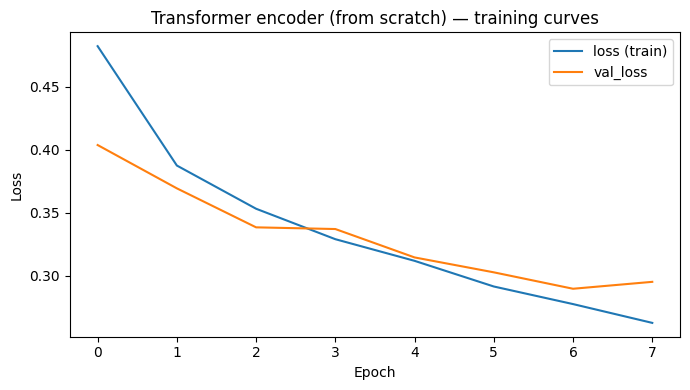

In [ ]:
"""
04_transformer_scratch.py
-------------------------------------------
CLASSIFIER #4 — Transformer encoder + classifier head, built in PyTorch.

Input embedding
        + Positional encoding              
    -> N stacked encoder blocks, each:
        - Multi-head self-attention        (Q, K, V matrices, h heads)
        - Add & Norm (residual + LayerNorm)
        - Position-wise FFN               
        - Add & Norm
    -> Mean pool across positions
    -> Small classifier head -> logit

We use nn.TransformerEncoderLayer for the encoder block (which contains
the multi-head attention, FFN, and LayerNorms already), and write the
positional encoding ourselves so the sin/cos pattern

WHY we choose it for our task:
- Tweets are short, so self-attention's O(L^2) cost is cheap
- Multi-head attention lets the model learn different "feature detectors"
- We use the ENCODER only.

REGULARIZATION:
- Dropout = 0.2 inside each transformer block + on classifier head
- Weight decay = 1e-5
- Early stopping on val loss

OPTIMIZER: Adam, lr=5e-4 (lower than #2/#3 because transformers are
           sensitive to learning rate)
LOSS:      BCEWithLogitsLoss

"""

import json
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

from data_loader import get_data
from tokenizer_util import Tokenizer, PAD_IDX


# ------------------------- Hyperparameters -------------------------
VOCAB_SIZE = 20_000
MAX_LEN = 60
EMBED_DIM = 64        # d_model
NUM_HEADS = 4         # h ; d_k = d_model / h = 16
FF_DIM = 128          # hidden width of the position-wise FFN
NUM_BLOCKS = 2        # how many encoder blocks to stack
DROPOUT = 0.2
BATCH_SIZE = 128
EPOCHS = 8
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-5
PATIENCE = 2
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------- Dataset -------------------------
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.ids = torch.tensor(
            tokenizer.encode_batch(texts, max_len), dtype=torch.long
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.ids[i], self.labels[i]


# ------------------------- Positional encoding -------------------------
class SinusoidalPositionalEncoding(nn.Module):
    """
    Implements the sin/cos positional encoding from Vaswani et al. 2017.
    For each position pos and dimension i:
        PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
    """
    def __init__(self, max_len, d_model):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float)
            * -(math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        # register_buffer = persistent but not a learnable parameter
        self.register_buffer("pe", pe.unsqueeze(0))    # (1, max_len, d_model)

    def forward(self, x):
        # x: (batch, L, d_model)
        return x + self.pe[:, : x.size(1), :]


# ------------------------- Model -------------------------
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim,
                 num_blocks, max_len, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=PAD_IDX)
        self.pos_enc = SinusoidalPositionalEncoding(max_len, embed_dim)

        # PyTorch's TransformerEncoderLayer implements exactly:
        #   x -> MultiHeadAttention -> +residual -> LayerNorm
        #     -> FFN(ReLU)            -> +residual -> LayerNorm
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,    # so input is (batch, seq, feat) not (seq, batch, feat)
            activation="relu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_blocks)

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1),
        )

    def forward(self, ids):
        # 1) Token embeddings + positional encoding
        x = self.embedding(ids)                    # (B, L, D)
        x = self.pos_enc(x)

        # 2) Build the padding mask: True where token is PAD
        #    The encoder will ignore those positions during attention.
        pad_mask = (ids == PAD_IDX)                # (B, L)

        # 3) Stack of transformer encoder blocks
        x = self.encoder(x, src_key_padding_mask=pad_mask)   # (B, L, D)

        # 4) Pool across positions, ignoring padding (mean over non-pad)
        mask = (~pad_mask).unsqueeze(-1).float()             # (B, L, 1)
        summed = (x * mask).sum(dim=1)                       # (B, D)
        counts = mask.sum(dim=1).clamp(min=1.0)              # (B, 1)
        pooled = summed / counts                             # (B, D)

        # 5) Classifier head
        logit = self.classifier(self.dropout(pooled)).squeeze(-1)
        return logit


# ------------------------- Helpers -------------------------
def run_epoch(model, loader, optimizer, criterion, train):
    model.train() if train else model.eval()
    total_loss, n, n_correct = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for ids, labels in loader:
            ids, labels = ids.to(DEVICE), labels.to(DEVICE)
            logits = model(ids)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            preds = (torch.sigmoid(logits) >= 0.5).float()
            n_correct += (preds == labels).sum().item()
            n += labels.size(0)
            total_loss += loss.item() * labels.size(0)
    return total_loss / n, n_correct / n


def main():
    torch.manual_seed(SEED)
    print(f"Device: {DEVICE}")

    X_train, X_test, y_train, y_test = get_data()
    n_val = int(0.1 * len(X_train))
    X_val, y_val = X_train[-n_val:], y_train[-n_val:]
    X_train, y_train = X_train[:-n_val], y_train[:-n_val]

    print("\nFitting tokenizer...")
    tokenizer = Tokenizer(vocab_size=VOCAB_SIZE, min_freq=2)
    tokenizer.fit(X_train)

    train_ds = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
    val_ds   = TweetDataset(X_val,   y_val,   tokenizer, MAX_LEN)
    test_ds  = TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

    model = TransformerClassifier(
        vocab_size=tokenizer.vocab_len,
        embed_dim=EMBED_DIM,
        num_heads=NUM_HEADS,
        ff_dim=FF_DIM,
        num_blocks=NUM_BLOCKS,
        max_len=MAX_LEN,
        dropout=DROPOUT,
    ).to(DEVICE)
    print("\nModel:")
    print(model)
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    )

    history = {"loss": [], "val_loss": [], "acc": [], "val_acc": []}
    best_val_loss, epochs_no_improve = float("inf"), 0
    best_state = None

    print("\nTraining Transformer encoder from scratch...")
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, criterion, True)
        va_loss, va_acc = run_epoch(model, val_loader,   optimizer, criterion, False)
        history["loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        print(f"  Epoch {epoch:2d}/{EPOCHS}  "
              f"loss={tr_loss:.4f} acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for ids, labels in test_loader:
            ids = ids.to(DEVICE)
            logits = model(ids)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy().astype(int))

    print("\n=== Test results ===")
    print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    print(classification_report(all_labels, all_preds, target_names=["fake", "real"]))
    print(confusion_matrix(all_labels, all_preds))

    torch.save({
        "model_state_dict": model.state_dict(),
        "config": {
            "vocab_size": tokenizer.vocab_len,
            "embed_dim": EMBED_DIM,
            "num_heads": NUM_HEADS,
            "ff_dim": FF_DIM,
            "num_blocks": NUM_BLOCKS,
            "max_len": MAX_LEN,
            "dropout": DROPOUT,
        },
    }, "model_04_transformer.pt")
    tokenizer.save("tokenizer_04.json")
    with open("history_04_transformer.json", "w") as f:
        json.dump(history, f)
    print("\nSaved: model_04_transformer.pt, tokenizer_04.json, history_04_transformer.json")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history["loss"], label="loss (train)")
    ax.plot(history["val_loss"], label="val_loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Transformer encoder (from scratch) — training curves")
    ax.legend()
    plt.tight_layout()
    plt.savefig("curves_04_transformer.png", dpi=150)
    print("Saved: curves_04_transformer.png")


if __name__ == "__main__":
    main()


## Classifier 5 — Fine-tuned DistilBERT

**The idea:** DistilBERT was already pretrained on billions of words from books and Wikipedia, so it understands English deeply before it ever sees our data. We just add a tiny classification head and fine-tune for 2 epochs.

-> pretrained models work well even on small datasets that would be insufficient to train a Transformer from scratch. Our adversarial filter, later will use this as the discriminator because it's expected to be the hardest to fool.

**choices:**
- `distilbert-base-uncased` : 40% smaller than full BERT, ~97% of the performance
- 2 epochs only (fine-tuning needs very few. easy to overfit otherwise)
- Learning rate `2e-5` with 10% linear warmup (standard BERT recipe)
- AdamW optimizer with gradient clipping at 1.0


In [9]:
!pip install transformers --quiet

In [ ]:
"""
Classifier 5 — Fine-tuned DistilBERT
"""
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import json
from data_loader import get_data

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 2
LEARNING_RATE = 2e-5
EVAL_EVERY_N_STEPS = 200      # measure val loss every N steps (controls plot density)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True,
                             padding="max_length", max_length=self.max_len,
                             return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "labels": torch.tensor(self.labels[idx], dtype=torch.long)}

# Load data + carve val set
X_train, X_test, y_train, y_test = get_data()
n_val = int(0.1 * len(X_train))
X_val, y_val = X_train[-n_val:], y_train[-n_val:]
X_train, y_train = X_train[:-n_val], y_train[:-n_val]

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)

train_loader = DataLoader(TweetDataset(X_train, y_train, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TweetDataset(X_val, y_val, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE)
test_loader  = DataLoader(TweetDataset(X_test, y_test, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

def compute_val_loss():
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            total += model(**batch).loss.item() * batch["labels"].size(0)
            n += batch["labels"].size(0)
    model.train()
    return total / n

# Track loss curves
history = {"steps": [], "loss": [], "val_loss": []}
running_loss, n_running, global_step = 0.0, 0, 0

print(f"\nTraining for {EPOCHS} epochs ({total_steps} steps total)...")
for epoch in range(EPOCHS):
    model.train()
    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(**batch)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step(); optimizer.zero_grad()

        running_loss += out.loss.item() * batch["labels"].size(0)
        n_running += batch["labels"].size(0)
        global_step += 1

        if global_step % EVAL_EVERY_N_STEPS == 0:
            tr = running_loss / n_running
            va = compute_val_loss()
            history["steps"].append(global_step)
            history["loss"].append(tr)
            history["val_loss"].append(va)
            print(f"  step {global_step}/{total_steps}  loss={tr:.4f}  val_loss={va:.4f}")
            running_loss, n_running = 0.0, 0
    print(f"  Epoch {epoch+1} done.")

# Final test evaluation
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        all_preds.extend(model(**batch).logits.argmax(-1).cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

print(f"\n=== Test results ===")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, target_names=["fake","real"]))
print(confusion_matrix(all_labels, all_preds))

# Training curve plot (same style as classifiers 2/3/4)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["steps"], history["loss"], label="loss (train)")
ax.plot(history["steps"], history["val_loss"], label="val_loss")
ax.set_xlabel("Training step"); ax.set_ylabel("Loss")
ax.set_title("DistilBERT (fine-tuned) — training curves")
ax.legend()
plt.tight_layout()
plt.savefig("curves_05_distilbert.png", dpi=150)
plt.show()

# Save model and history
model.save_pretrained("model_05_distilbert")
tokenizer.save_pretrained("model_05_distilbert")
with open("history_05_distilbert.json", "w") as f:
    json.dump(history, f)
print("\nSaved: model_05_distilbert/, history_05_distilbert.json, curves_05_distilbert.png")

## Comparison —> all classifiers side by side

Loading each trained model & re evaluates it on the same held out test set, prints a summary table (accuracy + F1), and saves two plots:
- `comparison_accuracy.png`  bar chart of test accuracy
- `training_curves.png` loss curves for each neural model

DistilBERT will appear as "(not trained)"


Device: cuda

Evaluating LogReg...
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299
Evaluating MLP...
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299
Evaluating BiLSTM...
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299
Evaluating Transformer (scratch)...
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299
Evaluating DistilBERT...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299

=== Model comparison ===
Model                          Accuracy         F1
--------------------------------------------------
LogReg (TF-IDF)                  0.5858     0.5379
Embedding+MLP                    0.7792     0.7863
BiLSTM                           0.8789     0.8797
Transformer (scratch)            0.8653     0.8655
DistilBERT (fine-tuned)          0.9750     0.9754

Saved: comparison_accuracy.png
Saved: training_curves.png


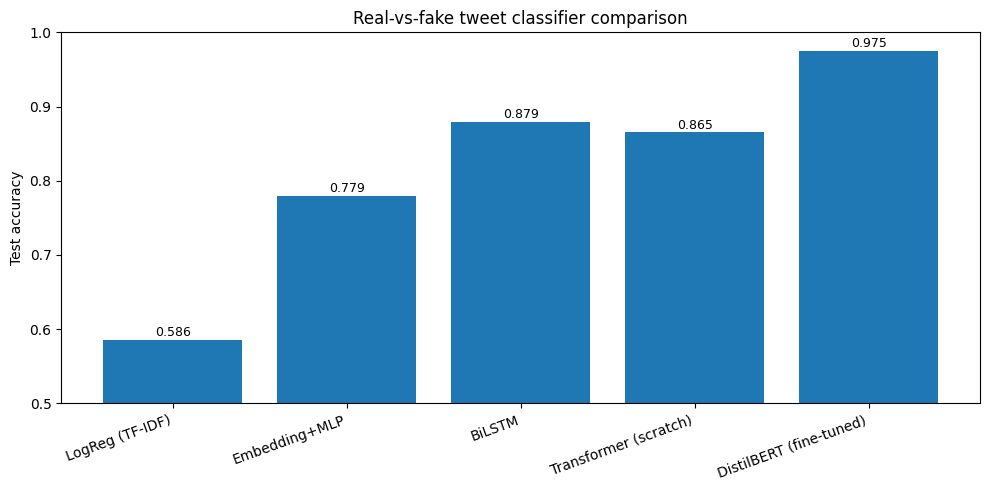

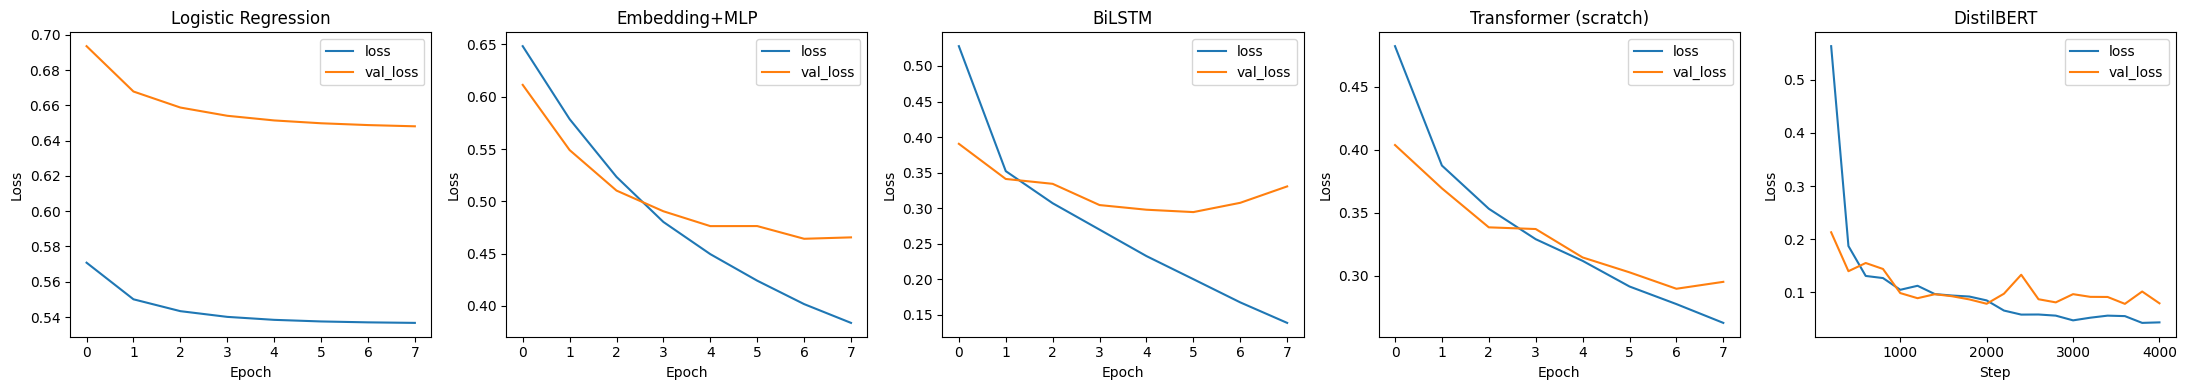

In [ ]:
"""
06_compare_results.py
---------------------------------------
prints a table and saves two plots:
   - comparison_accuracy.png   bar chart of test accuracy
   - training_curves.png       loss/val_loss curves for each NN model

"""

import json
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

from data_loader import get_data
from tokenizer_util import Tokenizer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---------------------------------------------------------------------------
# Per-model evaluators
# ---------------------------------------------------------------------------
def evaluate_logreg():
    import joblib
    if not os.path.exists("model_01_logreg.joblib"):
        return None
    vectorizer, model = joblib.load("model_01_logreg.joblib")
    _, X_test, _, y_test = get_data()
    y_pred = model.predict(vectorizer.transform(X_test))
    return accuracy_score(y_test, y_pred), f1_score(y_test, y_pred)


def _evaluate_pytorch(model_path, tok_path, model_builder, needs_lengths=False):
    """Generic loader for our PyTorch classifiers."""
    if not os.path.exists(model_path) or not os.path.exists(tok_path):
        return None
    from tokenizer_util import PAD_IDX

    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
    tokenizer = Tokenizer.load(tok_path)
    model = model_builder(ckpt["config"], tokenizer.vocab_len).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    _, X_test, _, y_test = get_data()
    max_len = ckpt["config"]["max_len"]
    ids = torch.tensor(tokenizer.encode_batch(X_test, max_len), dtype=torch.long)

    preds = []
    with torch.no_grad():
        for i in range(0, len(ids), 256):
            batch = ids[i:i+256].to(DEVICE)
            if needs_lengths:
                lengths = torch.tensor(
                    [max(1, (row != PAD_IDX).sum().item()) for row in batch],
                    dtype=torch.long,
                ).to(DEVICE)
                logits = model(batch, lengths)
            else:
                logits = model(batch)
            preds.extend((torch.sigmoid(logits) >= 0.5).long().cpu().numpy())

    return accuracy_score(y_test, preds), f1_score(y_test, preds)


def evaluate_mlp():
    return _evaluate_pytorch(
        "model_02_mlp.pt", "tokenizer_02.json",
        model_builder=lambda cfg, vs: _build_mlp(cfg, vs),
    )


def _build_mlp(cfg, vocab_size):
    """Rebuild the MLP architecture from 02_mlp_embedding.py."""
    import torch.nn as nn
    from tokenizer_util import PAD_IDX

    class EmbeddingMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, cfg["embed_dim"],
                                          padding_idx=PAD_IDX)
            self.fc1 = nn.Linear(cfg["embed_dim"], cfg["hidden_dim"])
            self.fc2 = nn.Linear(cfg["hidden_dim"], 1)
            self.dropout = nn.Dropout(cfg["dropout"])
            self.relu = nn.ReLU()

        def forward(self, x):
            emb = self.embedding(x)
            mask = (x != PAD_IDX).unsqueeze(-1).float()
            summed = (emb * mask).sum(dim=1)
            counts = mask.sum(dim=1).clamp(min=1.0)
            pooled = summed / counts
            h = self.relu(self.fc1(pooled))
            h = self.dropout(h)
            return self.fc2(h).squeeze(-1)
    return EmbeddingMLP()


def evaluate_lstm():
    return _evaluate_pytorch(
        "model_03_lstm.pt", "tokenizer_03.json",
        model_builder=lambda cfg, vs: _build_lstm(cfg, vs),
        needs_lengths=True,
    )


def _build_lstm(cfg, vocab_size):
    import torch.nn as nn
    from torch.nn.utils.rnn import pack_padded_sequence
    from tokenizer_util import PAD_IDX

    class BiLSTMClassifier(nn.Module):
        def __init__(self):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, cfg["embed_dim"],
                                          padding_idx=PAD_IDX)
            self.lstm = nn.LSTM(
                input_size=cfg["embed_dim"], hidden_size=cfg["hidden"],
                num_layers=cfg["num_layers"], bidirectional=True,
                batch_first=True,
                dropout=cfg["dropout"] if cfg["num_layers"] > 1 else 0.0,
            )
            self.dropout = nn.Dropout(cfg["dropout"])
            self.classifier = nn.Linear(2 * cfg["hidden"], 1)

        def forward(self, ids, lengths):
            emb = self.embedding(ids)
            packed = pack_padded_sequence(
                emb, lengths.cpu(),
                batch_first=True, enforce_sorted=False,
            )
            _, (h_n, _) = self.lstm(packed)
            h = torch.cat([h_n[-2], h_n[-1]], dim=-1)
            return self.classifier(self.dropout(h)).squeeze(-1)
    return BiLSTMClassifier()


def evaluate_transformer():
    return _evaluate_pytorch(
        "model_04_transformer.pt", "tokenizer_04.json",
        model_builder=lambda cfg, vs: _build_transformer(cfg, vs),
    )


def _build_transformer(cfg, vocab_size):
    import math
    import torch.nn as nn
    from tokenizer_util import PAD_IDX

    class SinusoidalPositionalEncoding(nn.Module):
        def __init__(self, max_len, d_model):
            super().__init__()
            pe = torch.zeros(max_len, d_model)
            pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
            div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float)
                            * -(math.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(pos * div)
            pe[:, 1::2] = torch.cos(pos * div)
            self.register_buffer("pe", pe.unsqueeze(0))

        def forward(self, x):
            return x + self.pe[:, : x.size(1), :]

    class TransformerClassifier(nn.Module):
        def __init__(self):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, cfg["embed_dim"],
                                          padding_idx=PAD_IDX)
            self.pos_enc = SinusoidalPositionalEncoding(
                cfg["max_len"], cfg["embed_dim"])
            layer = nn.TransformerEncoderLayer(
                d_model=cfg["embed_dim"], nhead=cfg["num_heads"],
                dim_feedforward=cfg["ff_dim"], dropout=cfg["dropout"],
                batch_first=True, activation="relu",
            )
            self.encoder = nn.TransformerEncoder(layer, num_layers=cfg["num_blocks"])
            self.dropout = nn.Dropout(cfg["dropout"])
            self.classifier = nn.Sequential(
                nn.Linear(cfg["embed_dim"], cfg["embed_dim"]),
                nn.ReLU(),
                nn.Dropout(cfg["dropout"]),
                nn.Linear(cfg["embed_dim"], 1),
            )

        def forward(self, ids):
            x = self.embedding(ids)
            x = self.pos_enc(x)
            pad_mask = (ids == PAD_IDX)
            x = self.encoder(x, src_key_padding_mask=pad_mask)
            mask = (~pad_mask).unsqueeze(-1).float()
            pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
            return self.classifier(self.dropout(pooled)).squeeze(-1)
    return TransformerClassifier()


def evaluate_distilbert():
    path = "model_05_distilbert"
    if not os.path.isdir(path):
        return None
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    tok = AutoTokenizer.from_pretrained(path)
    model = AutoModelForSequenceClassification.from_pretrained(path).to(DEVICE)
    model.eval()

    _, X_test, _, y_test = get_data()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_test), 64):
            batch = X_test[i:i+64]
            enc = tok(batch, truncation=True, padding=True,
                      max_length=64, return_tensors="pt").to(DEVICE)
            out = model(**enc).logits.argmax(dim=-1).cpu().numpy()
            preds.extend(out)
    return accuracy_score(y_test, preds), f1_score(y_test, preds)


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main():
    print(f"Device: {DEVICE}\n")
    results = {}

    print("Evaluating LogReg...");           results["LogReg (TF-IDF)"]         = evaluate_logreg()
    print("Evaluating MLP...");              results["Embedding+MLP"]           = evaluate_mlp()
    print("Evaluating BiLSTM...");           results["BiLSTM"]                  = evaluate_lstm()
    print("Evaluating Transformer (scratch)..."); results["Transformer (scratch)"] = evaluate_transformer()
    print("Evaluating DistilBERT...");       results["DistilBERT (fine-tuned)"] = evaluate_distilbert()

    # Print summary
    print("\n=== Model comparison ===")
    print(f"{'Model':<28s} {'Accuracy':>10s} {'F1':>10s}")
    print("-" * 50)
    for name, r in results.items():
        if r is None:
            print(f"{name:<28s} {'(not trained)':>22s}")
        else:
            acc, f1 = r
            print(f"{name:<28s} {acc:>10.4f} {f1:>10.4f}")

    # Bar chart
    trained = {k: v for k, v in results.items() if v is not None}
    if trained:
        names = list(trained.keys())
        accs = [v[0] for v in trained.values()]
        plt.figure(figsize=(10, 5))
        bars = plt.bar(names, accs)
        plt.ylim(0.5, 1.0)
        plt.ylabel("Test accuracy")
        plt.title("Real-vs-fake tweet classifier comparison")
        for bar, acc in zip(bars, accs):
            plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.005,
                     f"{acc:.3f}", ha="center", fontsize=9)
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()
        plt.savefig("comparison_accuracy.png", dpi=150)
        print("\nSaved: comparison_accuracy.png")

    # Training curves — all 5 classifiers
    # Note: DistilBERT history uses "steps" instead of "epoch" as the x-axis,
    # because it was logged per-step instead of per-epoch. We handle that in the plotting code below.
    histories = [
        ("Logistic Regression",   "history_01_logreg.json",      "epoch"),
        ("Embedding+MLP",         "history_02_mlp.json",         "epoch"),
        ("BiLSTM",                "history_03_lstm.json",        "epoch"),
        ("Transformer (scratch)", "history_04_transformer.json", "epoch"),
        ("DistilBERT",            "history_05_distilbert.json",  "step"),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    for ax, (label, path, x_kind) in zip(axes, histories):
        if not os.path.exists(path):
            ax.set_title(f"{label}\n(not trained)"); ax.axis("off"); continue
        with open(path) as f:
            h = json.load(f)
        if x_kind == "step" and "steps" in h:
            ax.plot(h["steps"], h["loss"], label="loss")
            ax.plot(h["steps"], h["val_loss"], label="val_loss")
            ax.set_xlabel("Step")
        else:
            ax.plot(h["loss"], label="loss")
            ax.plot(h["val_loss"], label="val_loss")
            ax.set_xlabel("Epoch")
        ax.set_title(label); ax.set_ylabel("Loss")
        ax.legend()
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    print("Saved: training_curves.png")


if __name__ == "__main__":
    main()


## Step 6 — Fake tweets from a fine-tuned LLM

The 4-gram Markov fakes are easy to spot —> they're locally fluent but globally incoherent. A more realistic adversary is a small language model fine-tuned on the same tweets we're trying to imitate.

we are going to :

1. Load `gpt2` (124M parameters)
2. Briefly fine-tune it on 10,000 real Trump tweets.
3. Sample 5,000 fake tweets from it with nucleus sampling (top-p = 0.9, temperature = 1.0)
4. Save as `fake_tweets_llm.json`

The question is: do the patterns the classifiers learned generalize, or were they really just learning to spot Markov-chain artifacts?


In [ ]:
%%writefile generate_llm_fakes.py
"""
generate_llm_fakes.py
---------------------
Fine-tunes GPT-2 (small) on real Trump tweets and samples N fake tweets from it.

Why: the Markov fakes are easy. An LLM produces more coherent fakes that
make the classification task much harder. We use this output as an
out of distribution test set for the trained classifiers.
"""

import json
import random

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2LMHeadModel, GPT2Tokenizer

from data_loader import load_real_tweets


# ------------------------- Hyperparameters -------------------------
MODEL_NAME      = "gpt2"           # 124M params
N_FT_SAMPLES    = 10_000           # real tweets used for fine-tuning
FT_EPOCHS       = 1
FT_BATCH_SIZE   = 8
LR              = 5e-5
MAX_FT_LEN      = 80
N_GENERATE      = 5_000            # number of fake tweets to produce
GEN_BATCH_SIZE  = 32
MAX_GEN_TOKENS  = 60
TEMPERATURE     = 1.0
TOP_P           = 0.9
SEED            = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------- Dataset -------------------------
class TweetsLMDataset(Dataset):
    """Pack each tweet between EOS tokens for causal LM training."""
    def __init__(self, tweets, tokenizer, max_len):
        eos = tokenizer.eos_token
        self.examples = []
        for t in tweets:
            ids = tokenizer.encode(eos + t + eos,
                                   truncation=True, max_length=max_len)
            self.examples.append(torch.tensor(ids, dtype=torch.long))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, i):
        return self.examples[i]


def collate(batch, pad_id):
    max_len = max(len(x) for x in batch)
    ids  = torch.full((len(batch), max_len), pad_id, dtype=torch.long)
    attn = torch.zeros((len(batch), max_len), dtype=torch.long)
    for i, x in enumerate(batch):
        ids[i, :len(x)]  = x
        attn[i, :len(x)] = 1
    return ids, attn


# ------------------------- Main -------------------------
def main():
    random.seed(SEED)
    torch.manual_seed(SEED)
    print(f"Device: {DEVICE}")

    real = load_real_tweets()
    random.shuffle(real)
    ft_tweets = real[:N_FT_SAMPLES]
    print(f"Fine-tuning on {len(ft_tweets):,} real tweets")

    # Tokenizer + model
    tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
    tokenizer.pad_token = tokenizer.eos_token
    model = GPT2LMHeadModel.from_pretrained(MODEL_NAME).to(DEVICE)
    model.config.pad_token_id = tokenizer.pad_token_id

    # Fine-tune
    ds = TweetsLMDataset(ft_tweets, tokenizer, MAX_FT_LEN)
    loader = DataLoader(
        ds, batch_size=FT_BATCH_SIZE, shuffle=True,
        collate_fn=lambda b: collate(b, tokenizer.pad_token_id),
    )
    optim = torch.optim.AdamW(model.parameters(), lr=LR)

    print(f"\nFine-tuning {MODEL_NAME} for {FT_EPOCHS} epoch(s)...")
    model.train()
    for ep in range(FT_EPOCHS):
        running = 0.0
        for step, (ids, attn) in enumerate(loader, 1):
            ids, attn = ids.to(DEVICE), attn.to(DEVICE)
            labels = ids.clone()
            labels[attn == 0] = -100        # ignore padding in loss
            out = model(input_ids=ids, attention_mask=attn, labels=labels)
            out.loss.backward()
            optim.step()
            optim.zero_grad()
            running += out.loss.item()
            if step % 100 == 0:
                print(f"  ep {ep+1} step {step}/{len(loader)}  "
                      f"loss={running/step:.4f}")
        print(f"  Epoch {ep+1} done. avg loss={running/len(loader):.4f}")

    # Generate
    print(f"\nGenerating {N_GENERATE:,} fake tweets...")
    model.eval()
    fakes = []
    eos_id = tokenizer.eos_token_id
    safety = 0
    with torch.no_grad():
        while len(fakes) < N_GENERATE and safety < 1000:
            safety += 1
            input_ids = torch.full((GEN_BATCH_SIZE, 1), eos_id,
                                   dtype=torch.long, device=DEVICE)
            out = model.generate(
                input_ids,
                max_new_tokens=MAX_GEN_TOKENS,
                do_sample=True,
                temperature=TEMPERATURE,
                top_p=TOP_P,
                pad_token_id=eos_id,
            )
            for row in out:
                txt = tokenizer.decode(row[1:], skip_special_tokens=True).strip()
                if 5 <= len(txt) <= 400:
                    fakes.append(txt)
                if len(fakes) >= N_GENERATE:
                    break
            if safety % 10 == 0:
                print(f"  Generated {len(fakes):,}/{N_GENERATE:,}")

    fakes = fakes[:N_GENERATE]
    with open("fake_tweets_llm.json", "w", encoding="utf-8") as f:
        json.dump(fakes, f)
    print(f"\nSaved fake_tweets_llm.json with {len(fakes):,} tweets")
    print("\nSample LLM-generated tweets:")
    for s in fakes[:5]:
        print(f"  - {s[:140]}")


if __name__ == "__main__":
    main()


Writing generate_llm_fakes.py


In [ ]:
!python generate_llm_fakes.py

## Step 7 — Testing the classifiers on LLM fakes

Now the interesting part. Each classifier (LogReg, MLP, BiLSTM, Transformer) was trained to tell **real** tweets apart from **4-gram Markov** fakes.

We construct a fresh balanced evaluation set:

- **Real** = real tweets sampled from the original held-out test set
- **Fake** = the 5,000 LLM-generated tweets from the previous cell

Then we measure each saved model's accuracy and F1 on this new set, and plot it side-by-side with the original Markov-fake numbers from Step 5.

Expected result: every classifier should do *worse* on LLM fakes than on Markov fakes. by how much tells us how much each was relying on cheap surface level cues vs. genuinely modelling Trump's style.


Device: cuda
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299

LLM eval set: 5,000 real + 5,000 LLM-fake = 10,000 tweets

Evaluating LogReg (TF-IDF)...
  Markov fakes:  acc=0.5907  F1=0.5675
  LLM fakes:     acc=0.4526  F1=0.4940
  Drop in acc:   +0.1381

Evaluating Embedding+MLP...
  Markov fakes:  acc=0.7792  F1=0.7863
  LLM fakes:     acc=0.5102  F1=0.6235
  Drop in acc:   +0.2690

Evaluating BiLSTM...
  Markov fakes:  acc=0.8789  F1=0.8797
  LLM fakes:     acc=0.5233  F1=0.6510
  Drop in acc:   +0.3556

Evaluating Transformer (scratch)...
  Markov fakes:  acc=0.8653  F1=0.8655
  LLM fakes:     acc=0.5335  F1=0.6501
  Drop in acc:   +0.3318

Evaluating DistilBERT (fine-tuned)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Markov fakes:  acc=0.9749  F1=0.9753
  LLM fakes:     acc=0.5085  F1=0.6682
  Drop in acc:   +0.4664

Model                    | Markov acc    LLM acc |  Markov F1     LLM F1
------------------------------------------------------------------------
LogReg (TF-IDF)          |     0.5907     0.4526 |     0.5675     0.4940
Embedding+MLP            |     0.7792     0.5102 |     0.7863     0.6235
BiLSTM                   |     0.8789     0.5233 |     0.8797     0.6510
Transformer (scratch)    |     0.8653     0.5335 |     0.8655     0.6501
DistilBERT (fine-tuned)  |     0.9749     0.5085 |     0.9753     0.6682


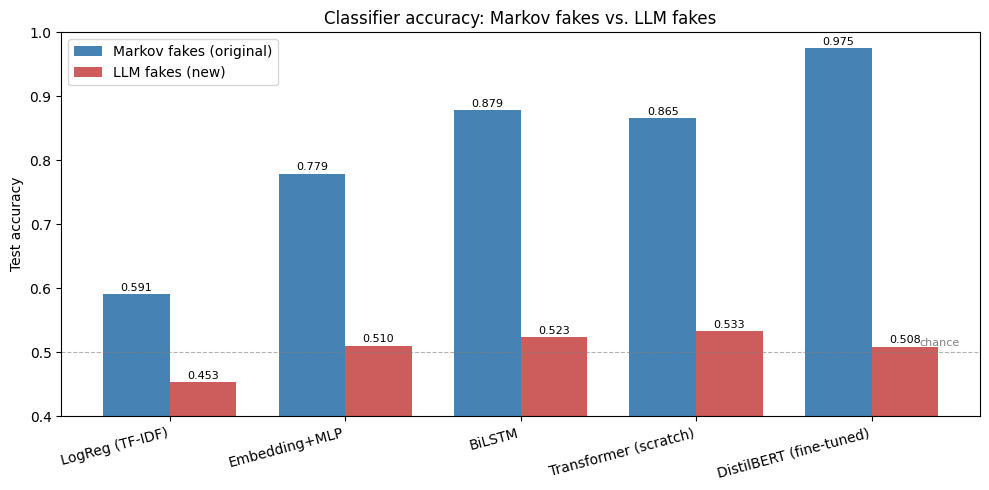


Saved: comparison_llm_vs_markov.png
Saved: results_llm_eval.json


In [ ]:
"""
Evaluate every trained classifier on the LLM-generated fakes and compare to
its performance on the original Markov fakes.
"""

import json
import math
import os

import joblib
import numpy as np
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

from data_loader import get_data
from tokenizer_util import Tokenizer, PAD_IDX

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


# ---------------------------------------------------------------------------
# 1. Build the LLM evaluation set: real test tweets + LLM fakes (balanced)
# ---------------------------------------------------------------------------
_, X_test, _, y_test = get_data()
real_test = [x for x, y in zip(X_test, y_test) if y == 1]

with open("fake_tweets_llm.json") as f:
    llm_fakes = json.load(f)

n = min(len(real_test), len(llm_fakes))
rng = np.random.default_rng(42)
real_sample = [real_test[i] for i in rng.choice(len(real_test), n, replace=False)]
llm_sample  = [llm_fakes[i] for i in rng.choice(len(llm_fakes), n, replace=False)]

X_llm = real_sample + llm_sample
y_llm = [1] * n + [0] * n
print(f"\nLLM eval set: {n:,} real + {n:,} LLM-fake = {2*n:,} tweets")


# ---------------------------------------------------------------------------
# 2. Reusable evaluator (accepts custom test set)
# ---------------------------------------------------------------------------
def _evaluate_pytorch(model_path, tok_path, model_builder, X_eval, y_eval,
                      needs_lengths=False):
    if not os.path.exists(model_path) or not os.path.exists(tok_path):
        return None
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
    tokenizer = Tokenizer.load(tok_path)
    model = model_builder(ckpt["config"], tokenizer.vocab_len).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    max_len = ckpt["config"]["max_len"]
    ids = torch.tensor(tokenizer.encode_batch(X_eval, max_len), dtype=torch.long)

    preds = []
    with torch.no_grad():
        for i in range(0, len(ids), 256):
            batch = ids[i:i+256].to(DEVICE)
            if needs_lengths:
                lengths = torch.tensor(
                    [max(1, (row != PAD_IDX).sum().item()) for row in batch],
                    dtype=torch.long,
                ).to(DEVICE)
                logits = model(batch, lengths)
            else:
                logits = model(batch)
            preds.extend((torch.sigmoid(logits) >= 0.5).long().cpu().numpy())
    return accuracy_score(y_eval, preds), f1_score(y_eval, preds)


def _build_mlp(cfg, vocab_size):
    class EmbeddingMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, cfg["embed_dim"],
                                          padding_idx=PAD_IDX)
            self.fc1 = nn.Linear(cfg["embed_dim"], cfg["hidden_dim"])
            self.fc2 = nn.Linear(cfg["hidden_dim"], 1)
            self.dropout = nn.Dropout(cfg["dropout"])
            self.relu = nn.ReLU()
        def forward(self, x):
            emb = self.embedding(x)
            mask = (x != PAD_IDX).unsqueeze(-1).float()
            pooled = (emb * mask).sum(1) / mask.sum(1).clamp(min=1.0)
            return self.fc2(self.dropout(self.relu(self.fc1(pooled)))).squeeze(-1)
    return EmbeddingMLP()


def _build_lstm(cfg, vocab_size):
    class BiLSTMClassifier(nn.Module):
        def __init__(self):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, cfg["embed_dim"],
                                          padding_idx=PAD_IDX)
            self.lstm = nn.LSTM(
                input_size=cfg["embed_dim"], hidden_size=cfg["hidden"],
                num_layers=cfg["num_layers"], bidirectional=True,
                batch_first=True,
                dropout=cfg["dropout"] if cfg["num_layers"] > 1 else 0.0,
            )
            self.dropout = nn.Dropout(cfg["dropout"])
            self.classifier = nn.Linear(2 * cfg["hidden"], 1)
        def forward(self, ids, lengths):
            emb = self.embedding(ids)
            packed = pack_padded_sequence(emb, lengths.cpu(),
                                          batch_first=True, enforce_sorted=False)
            _, (h, _) = self.lstm(packed)
            h = torch.cat([h[-2], h[-1]], dim=-1)
            return self.classifier(self.dropout(h)).squeeze(-1)
    return BiLSTMClassifier()


def _build_transformer(cfg, vocab_size):
    class SinusoidalPositionalEncoding(nn.Module):
        def __init__(self, max_len, d_model):
            super().__init__()
            pe = torch.zeros(max_len, d_model)
            pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
            div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float)
                            * -(math.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(pos * div)
            pe[:, 1::2] = torch.cos(pos * div)
            self.register_buffer("pe", pe.unsqueeze(0))
        def forward(self, x):
            return x + self.pe[:, :x.size(1), :]

    class TransformerClassifier(nn.Module):
        def __init__(self):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, cfg["embed_dim"],
                                          padding_idx=PAD_IDX)
            self.pos_enc = SinusoidalPositionalEncoding(
                cfg["max_len"], cfg["embed_dim"])
            layer = nn.TransformerEncoderLayer(
                d_model=cfg["embed_dim"], nhead=cfg["num_heads"],
                dim_feedforward=cfg["ff_dim"], dropout=cfg["dropout"],
                batch_first=True, activation="relu",
            )
            self.encoder = nn.TransformerEncoder(layer, num_layers=cfg["num_blocks"])
            self.dropout = nn.Dropout(cfg["dropout"])
            self.classifier = nn.Sequential(
                nn.Linear(cfg["embed_dim"], cfg["embed_dim"]),
                nn.ReLU(),
                nn.Dropout(cfg["dropout"]),
                nn.Linear(cfg["embed_dim"], 1),
            )
        def forward(self, ids):
            x = self.embedding(ids)
            x = self.pos_enc(x)
            pad_mask = (ids == PAD_IDX)
            x = self.encoder(x, src_key_padding_mask=pad_mask)
            mask = (~pad_mask).unsqueeze(-1).float()
            pooled = (x * mask).sum(1) / mask.sum(1).clamp(min=1.0)
            return self.classifier(self.dropout(pooled)).squeeze(-1)
    return TransformerClassifier()

def eval_distilbert(X_eval, y_eval):
    path = "model_05_distilbert"
    if not os.path.isdir(path):
        return None
    from transformers import AutoTokenizer, AutoModelForSequenceClassification

    tok = AutoTokenizer.from_pretrained(path)
    model = AutoModelForSequenceClassification.from_pretrained(path).to(DEVICE)
    model.eval()

    preds = []
    with torch.no_grad():
        for i in range(0, len(X_eval), 64):
            batch = X_eval[i:i+64]
            enc = tok(batch, truncation=True, padding=True,
                      max_length=64, return_tensors="pt").to(DEVICE)
            preds.extend(model(**enc).logits.argmax(dim=-1).cpu().numpy())
    return accuracy_score(y_eval, preds), f1_score(y_eval, preds)

def eval_logreg(X_eval, y_eval):
    if not os.path.exists("model_01_logreg.joblib"):
        return None
    vectorizer, model = joblib.load("model_01_logreg.joblib")
    y_pred = model.predict(vectorizer.transform(X_eval))
    return accuracy_score(y_eval, y_pred), f1_score(y_eval, y_pred)


# ---------------------------------------------------------------------------
# 3. Run every classifier on BOTH the Markov set (X_test) and the LLM set
# ---------------------------------------------------------------------------
SPECS = [
    ("LogReg (TF-IDF)",       lambda X, y: eval_logreg(X, y)),
    ("Embedding+MLP",         lambda X, y: _evaluate_pytorch(
        "model_02_mlp.pt", "tokenizer_02.json", _build_mlp, X, y)),
    ("BiLSTM",                lambda X, y: _evaluate_pytorch(
        "model_03_lstm.pt", "tokenizer_03.json", _build_lstm, X, y,
        needs_lengths=True)),
    ("Transformer (scratch)", lambda X, y: _evaluate_pytorch(
        "model_04_transformer.pt", "tokenizer_04.json", _build_transformer, X, y)),
    ("DistilBERT (fine-tuned)", lambda X, y: eval_distilbert(X, y)),   # ← NEW
]

results = {}
for name, fn in SPECS:
    print(f"\nEvaluating {name}...")
    on_markov = fn(X_test, y_test)
    on_llm    = fn(X_llm,  y_llm)
    if on_markov is None or on_llm is None:
        print("  (model not found on disk — train it first)")
        continue
    am, fm = on_markov
    al, fl = on_llm
    results[name] = {"markov": (am, fm), "llm": (al, fl)}
    print(f"  Markov fakes:  acc={am:.4f}  F1={fm:.4f}")
    print(f"  LLM fakes:     acc={al:.4f}  F1={fl:.4f}")
    print(f"  Drop in acc:   {am - al:+.4f}")


# ---------------------------------------------------------------------------
# 4. Summary table
# ---------------------------------------------------------------------------
print("\n" + "=" * 72)
print(f"{'Model':<24s} | {'Markov acc':>10s} {'LLM acc':>10s} | {'Markov F1':>10s} {'LLM F1':>10s}")
print("-" * 72)
for name, r in results.items():
    am, fm = r["markov"]
    al, fl = r["llm"]
    print(f"{name:<24s} | {am:>10.4f} {al:>10.4f} | {fm:>10.4f} {fl:>10.4f}")
print("=" * 72)


# ---------------------------------------------------------------------------
# 5. Side-by-side bar chart
# ---------------------------------------------------------------------------
if results:
    names    = list(results.keys())
    acc_mk   = [results[n]["markov"][0] for n in names]
    acc_llm_ = [results[n]["llm"][0]    for n in names]

    x = np.arange(len(names))
    width = 0.38

    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x - width/2, acc_mk,   width,
                label="Markov fakes (original)", color="steelblue")
    b2 = ax.bar(x + width/2, acc_llm_, width,
                label="LLM fakes (new)", color="indianred")

    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel("Test accuracy")
    ax.set_title("Classifier accuracy: Markov fakes vs. LLM fakes")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha="right")
    ax.legend()
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(len(names) - 0.5, 0.51, "chance",
            color="gray", fontsize=8, ha="right")

    for bars in (b1, b2):
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, h + 0.005,
                    f"{h:.3f}", ha="center", fontsize=8)

    plt.tight_layout()
    plt.savefig("comparison_llm_vs_markov.png", dpi=150)
    plt.show()
    print("\nSaved: comparison_llm_vs_markov.png")

    with open("results_llm_eval.json", "w") as f:
        json.dump(results, f, indent=2)
    print("Saved: results_llm_eval.json")


## Download all results




In [ ]:
import os
import zipfile

# Collect every output file produced by the notebook
patterns = ["model_", "tokenizer_", "history_", "curves_", "comparison_", "training_curves", "results_step4", "results_llm_eval", "fake_tweets_llm"]
keep = [f for f in os.listdir(".")
        if any(f.startswith(p) for p in patterns)
        and f.endswith((".pt", ".joblib", ".json", ".png", ".csv"))]

if not keep:
    print("No result files found yet — run the classifier cells first.")
else:
    with zipfile.ZipFile("results.zip", "w", compression=zipfile.ZIP_DEFLATED) as z:
        for f in sorted(keep):
            z.write(f)
            print(f"  added: {f}  ({os.path.getsize(f)/1024:,.0f} KB)")



In [13]:
from google.colab import files
files.download("curves_01_logreg.png")
files.download("history_01_logreg.json")
files.download("curves_05_distilbert.png")
files.download("history_05_distilbert.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>